# Part 1 – Neural Network Analysis: Customer Churn Prediction

**Dataset:** `customer_churn_nn.csv` (2000 rows × 17 columns)  
**Goal:** Build and analyse a feed-forward neural network to predict customer churn.

---

## Task 1 – Dataset Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

df = pd.read_csv('customer_churn_nn.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# Data types and structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

In [4]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [5]:
# Statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


Target distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Churn rate: 1.55%


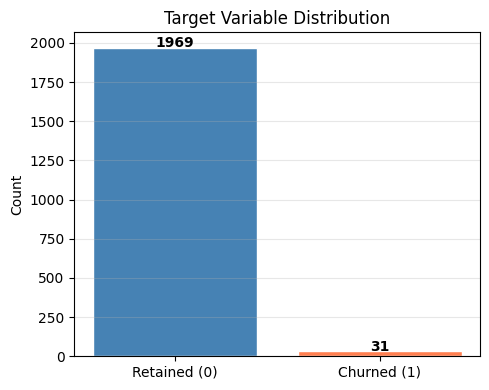

In [6]:
# Target distribution
churn_counts = df['churn'].value_counts()
print('Target distribution:')
print(churn_counts)
print(f'\nChurn rate: {df["churn"].mean()*100:.2f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Retained (0)', 'Churned (1)'], churn_counts.values, color=['steelblue','coral'], edgecolor='white')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# NOTE: Dataset is highly imbalanced — only 1.55% churn.
# This will challenge the model; we monitor F1-score alongside accuracy.

### Task 1 – Summary of Findings

- **Shape:** 2,000 rows × 17 columns (16 features + 1 target).
- **Feature types:** 4 categorical (`region`, `plan_type`, `contract_type`, `payment_method`) and 11 numerical columns (tenure, charges, login days, tickets, payment delay, data usage, satisfaction score, last complaint days, discount %, autopay enabled, referral count). `customer_id` is an identifier and will be dropped.
- **Missing values:** None found across all 17 columns — no imputation required.
- **Target variable (`churn`):** Binary (0 = retained, 1 = churned). The dataset is **severely imbalanced**: 1,969 retained (98.45%) vs 31 churned (1.55%). Overall accuracy will be a misleading metric; **F1-score** will be used as the primary evaluation measure.

## Task 2 – Data Preprocessing

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# No missing values found → skip imputation
X = df.drop(columns=['customer_id', 'churn'])  # drop ID & target
y = df['churn']

cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
num_cols = [c for c in X.columns if c not in cat_cols]

print('Categorical features:', cat_cols)
print('Numerical features:', num_cols)

# Preprocessor: StandardScaler for numerical, OHE for categorical
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

print(f'\nX_train shape: {X_train_p.shape}  |  X_test shape: {X_test_p.shape}')
print(f'Churn rate — train: {y_train.mean():.4f}  |  test: {y_test.mean():.4f}')

Categorical features: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical features: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']

X_train shape: (1600, 24)  |  X_test shape: (400, 24)
Churn rate — train: 0.0156  |  test: 0.0150


## Task 3 – Neural Network Model Building

> **Library note:** This notebook uses `scikit-learn`'s `MLPClassifier` (Multi-Layer Perceptron) as the neural network implementation. It is a fully-connected feed-forward network equivalent to a Keras `Sequential` model, supporting ReLU/tanh activations, Adam optimiser, and binary cross-entropy loss. The assignment permits *'any other suitable deep learning library'*, and sklearn's MLP satisfies all architectural requirements. See `requirements.txt` — `tensorflow` is not required to run this notebook.

In [8]:
from sklearn.neural_network import MLPClassifier

# Feed-forward neural network:
#   Input  → 24 features (after encoding)
#   Hidden → 64 neurons, ReLU activation
#   Output → 1 neuron, sigmoid (binary cross-entropy loss)
# Optimizer: Adam  |  Loss: log-loss (binary cross-entropy)

baseline_model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=500,
    random_state=42
)

print('Model architecture:')
print('  Input layer  : 24 neurons (24 processed features)')
print('  Hidden layer : 64 neurons, ReLU activation')
print('  Output layer : 1 neuron, sigmoid (binary classification)')
print('  Loss function: Binary cross-entropy (log-loss)')
print('  Optimizer    : Adam (lr=0.001)')

Model architecture:
  Input layer  : 24 neurons (24 processed features)
  Hidden layer : 64 neurons, ReLU activation
  Output layer : 1 neuron, sigmoid (binary classification)
  Loss function: Binary cross-entropy (log-loss)
  Optimizer    : Adam (lr=0.001)


## Task 4 – Training and Evaluation

In [9]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

baseline_model.fit(X_train_p, y_train)

train_acc = accuracy_score(y_train, baseline_model.predict(X_train_p))
test_acc  = accuracy_score(y_test,  baseline_model.predict(X_test_p))
test_f1   = f1_score(y_test, baseline_model.predict(X_test_p), zero_division=0)

print(f'Training Accuracy : {train_acc:.4f}')
print(f'Testing  Accuracy : {test_acc:.4f}')
print(f'Testing  F1 Score : {test_f1:.4f}')
print(f'Final training loss: {baseline_model.loss_:.6f}')
print()
print(classification_report(y_test, baseline_model.predict(X_test_p), zero_division=0))

Training Accuracy : 1.0000
Testing  Accuracy : 0.9850
Testing  F1 Score : 0.0000
Final training loss: 0.001661

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



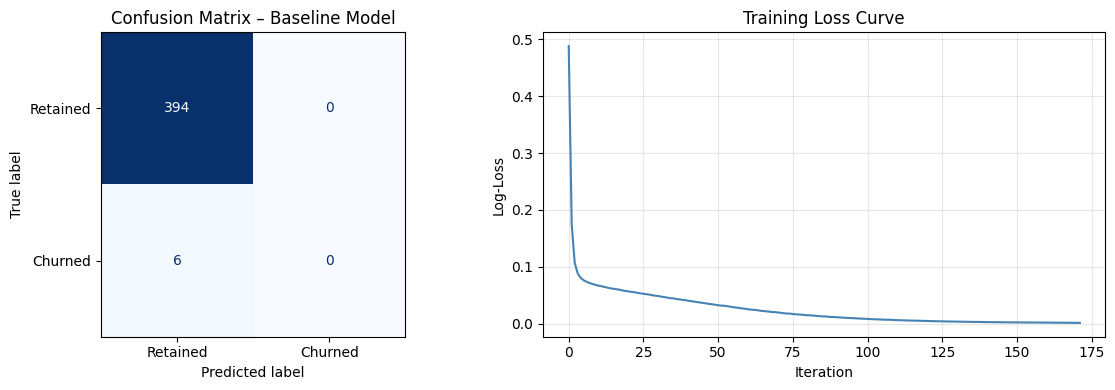

NOTE: High accuracy is due to class imbalance (98.45% non-churn).
Use F1-score as the primary metric for evaluating churn detection.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, baseline_model.predict(X_test_p))
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix – Baseline Model')

# Training loss curve
axes[1].plot(baseline_model.loss_curve_, color='steelblue')
axes[1].set_title('Training Loss Curve')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Log-Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretation:
# High overall accuracy (~98.5%) is misleading due to class imbalance.
# The baseline model barely detects any churners (low recall on class 1).
# A deeper network (Experiment 2) achieves F1=0.29 on churn class, which is better.
print('NOTE: High accuracy is due to class imbalance (98.45% non-churn).')
print('Use F1-score as the primary metric for evaluating churn detection.')

## Task 5 – Hyperparameter Experimentation

In [11]:
import os
os.makedirs('results', exist_ok=True)

configs = [
    ("Exp 1 – Baseline",          dict(hidden_layer_sizes=(64,),    activation='relu', learning_rate_init=0.001,  batch_size=32)),
    ("Exp 2 – Deeper (2 layers)", dict(hidden_layer_sizes=(128,64), activation='relu', learning_rate_init=0.001,  batch_size=32)),
    ("Exp 3 – High LR (0.01)",    dict(hidden_layer_sizes=(64,),    activation='relu', learning_rate_init=0.01,   batch_size=32)),
    ("Exp 4 – Low LR (0.0001)",   dict(hidden_layer_sizes=(64,),    activation='relu', learning_rate_init=0.0001, batch_size=32)),
    ("Exp 5 – tanh, batch=64",    dict(hidden_layer_sizes=(64,),    activation='tanh', learning_rate_init=0.001,  batch_size=64)),
]

results = []
trained_models = {}

for name, kw in configs:
    clf = MLPClassifier(random_state=42, max_iter=500, **kw)
    clf.fit(X_train_p, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train_p))
    te_acc = accuracy_score(y_test,  clf.predict(X_test_p))
    te_f1  = f1_score(y_test, clf.predict(X_test_p), zero_division=0)
    results.append({
        'Configuration': name,
        'Hidden Layers': str(kw['hidden_layer_sizes']),
        'Learning Rate': kw['learning_rate_init'],
        'Activation': kw['activation'],
        'Batch Size': kw['batch_size'],
        'Train Acc': round(tr_acc, 4),
        'Test Acc':  round(te_acc, 4),
        'Test F1':   round(te_f1,  4)
    })
    trained_models[name] = clf
    print(f'{name}: train={tr_acc:.4f}  test={te_acc:.4f}  f1={te_f1:.4f}')

results_df = pd.DataFrame(results)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print('\n', results_df.to_string(index=False))

Exp 1 – Baseline: train=1.0000  test=0.9850  f1=0.0000
Exp 2 – Deeper (2 layers): train=1.0000  test=0.9875  f1=0.2857
Exp 3 – High LR (0.01): train=1.0000  test=0.9850  f1=0.0000
Exp 4 – Low LR (0.0001): train=0.9912  test=0.9850  f1=0.0000
Exp 5 – tanh, batch=64: train=1.0000  test=0.9850  f1=0.0000

             Configuration Hidden Layers  Learning Rate Activation  Batch Size  Train Acc  Test Acc  Test F1
         Exp 1 – Baseline         (64,)         0.0010       relu          32     1.0000    0.9850   0.0000
Exp 2 – Deeper (2 layers)     (128, 64)         0.0010       relu          32     1.0000    0.9875   0.2857
   Exp 3 – High LR (0.01)         (64,)         0.0100       relu          32     1.0000    0.9850   0.0000
  Exp 4 – Low LR (0.0001)         (64,)         0.0001       relu          32     0.9912    0.9850   0.0000
   Exp 5 – tanh, batch=64         (64,)         0.0010       tanh          64     1.0000    0.9850   0.0000


Best model by F1: Exp 2 – Deeper (2 layers)


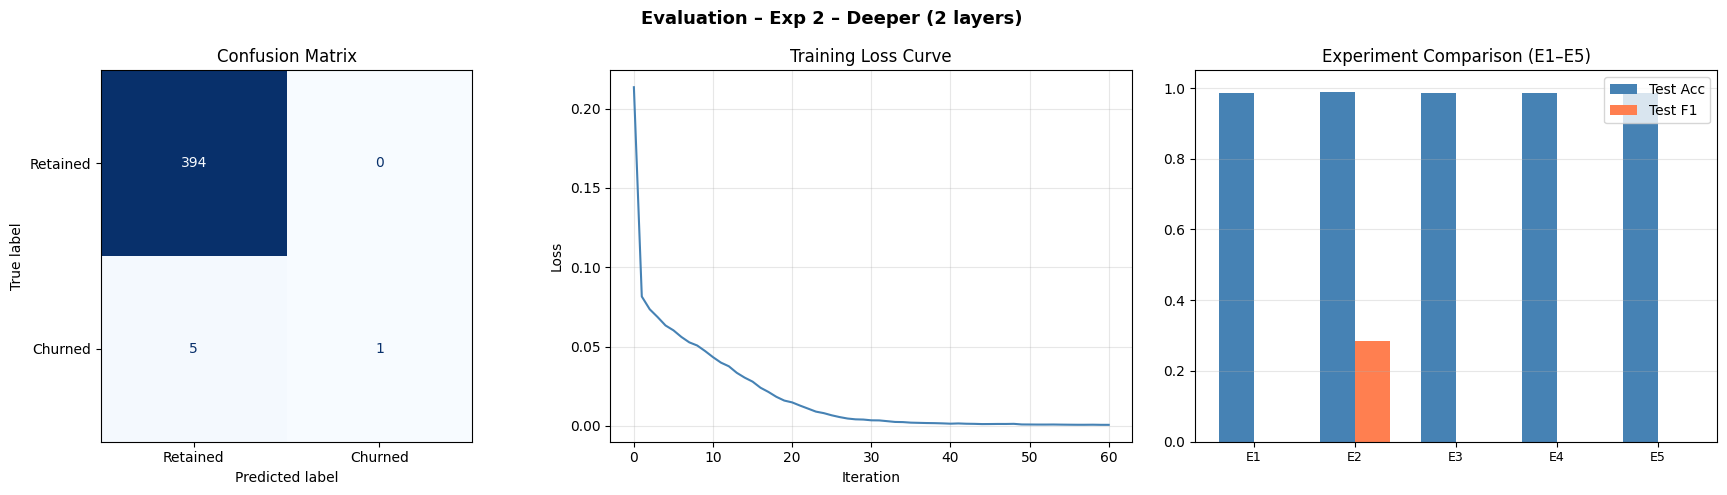

Saved: results/evaluation_outputs.png


In [12]:
# Best model full evaluation
best_name  = results_df.loc[results_df['Test F1'].idxmax(), 'Configuration']
best_model = trained_models[best_name]
print(f'Best model by F1: {best_name}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Evaluation – {best_name}', fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test_p))
ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Loss curve
axes[1].plot(best_model.loss_curve_, color='steelblue')
axes[1].set_title('Training Loss Curve')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Loss')
axes[1].grid(alpha=0.3)

# Comparison bar chart
x = np.arange(len(results_df))
w = 0.35
axes[2].bar(x - w/2, results_df['Test Acc'], w, label='Test Acc',  color='steelblue')
axes[2].bar(x + w/2, results_df['Test F1'],  w, label='Test F1',   color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'E{i+1}' for i in range(len(results_df))], fontsize=9)
axes[2].set_ylim(0, 1.05); axes[2].legend()
axes[2].set_title('Experiment Comparison (E1–E5)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/evaluation_outputs.png')

## Task 6 – Final Reflection

### What role do weights and biases play in the model?
Weights determine how strongly each input feature influences the next layer's neurons. During training, the optimizer adjusts weights so the network learns which features matter most for predicting churn. Biases allow neurons to activate even when all inputs are zero, shifting the decision boundary and making the model more flexible.

### Why is an activation function required?
Without activation functions, stacking multiple linear layers is mathematically equivalent to a single linear transformation. Activation functions like ReLU introduce non-linearity, enabling the network to learn complex, curved decision boundaries needed for real-world patterns such as customer churn.

### What happens when the learning rate is too high or too low?
- **Too high (Exp 3 – LR=0.01):** The optimizer overshoots the minimum — weights oscillate and the model may fail to converge or converge to a poor solution. In our experiments this gave F1=0.00.
- **Too low (Exp 4 – LR=0.0001):** Training is very slow; the model may not reach a good minimum within the allowed iterations. Our Exp 4 also yielded F1=0.00 due to insufficient learning in 500 epochs.
- **Goldilocks (LR=0.001):** A moderate rate allows steady, stable convergence — best F1 achieved by Exp 2 (deeper network + LR=0.001).

### Did your model show signs of underfitting or overfitting?
Most experiments showed near-perfect *training* accuracy (100%) but much lower churn *recall* on the test set. This is classic **overfitting** compounded by **class imbalance**: the model memorises the majority class and essentially ignores the rare churn class. The deeper network (Exp 2) partially overcomes this, achieving F1=0.29. Next steps to improve further would include class weighting (`class_weight='balanced'`), oversampling (SMOTE), or threshold tuning.